# Lista 02 - Estatística

**Questão 01 - Usando o mesmo portfolio da sua lista anterior, normalize os retornos logarítmicos,( z-score). O que ele significa?**

In [ ]:
### Escreva aqui seu código para responder a questão 1.
### Para responder a parte interpretativa, crie uma nova célula de texto!
import pandas as pd

df = pd.read_excel("dados_lista1.xlsx",
                   skiprows=3,
                   index_col=0
                   )
df.columns = df.columns.str.strip()
df = df.apply(pd.to_numeric, errors = 'coerce')
df = df.dropna()
df.rename(columns={'Fechamento\najust p/ prov\nEm moeda orig': 'IBOV'}, inplace=True)
display(df)




import numpy as np

df['retorno_log1'] = np.log(df['Petrobras']) - np.log(df['Petrobras'].shift(1))
df['retorno_log2'] = np.log(df['Vale']) - np.log(df['Vale'].shift(1))
df['retorno_log3'] = np.log(df['Itau']) - np.log(df['Itau'].shift(1))
df['retorno_log4'] = np.log(df['BB']) - np.log(df['BB'].shift(1))
df['retorno_log5'] = np.log(df['B3']) - np.log(df['B3'].shift(1))
df['retorno_log6'] = np.log(df['IBOV']) - np.log(df['IBOV'].shift(1))

# Z-score:
df['zscore Petrobras'] = (df['retorno_log1'] - df['retorno_log1'].mean()) / df['retorno_log1'].std()
df['zscore Vale'] = (df['retorno_log2'] - df['retorno_log2'].mean()) / df['retorno_log2'].std()
df['zscore Itau'] = (df['retorno_log3'] - df['retorno_log3'].mean()) / df['retorno_log3'].std()
df['zscore BB'] = (df['retorno_log4'] - df['retorno_log4'].mean()) / df['retorno_log4'].std()
df['zscore B3'] = (df['retorno_log5'] - df['retorno_log5'].mean()) / df['retorno_log5'].std()
df['zscore IBOV'] = (df['retorno_log6'] - df['retorno_log6'].mean()) / df['retorno_log6'].std()

df = df.dropna()
display((df[['zscore Petrobras', 'zscore Vale', 'zscore Itau', 'zscore BB', 'zscore B3', 'zscore IBOV']]))

,Petrobras,Vale,Itau,BB,B3,IBOV
Data,,,,,,
2017-01-02,3.682785,12.464374,9.392537,7.519156,3.872176,59588.00
2017-01-03,3.893804,13.016467,9.790312,7.863169,4.031534,61813.00
2017-01-04,3.893804,12.782698,9.832331,7.822215,4.107646,61589.00
2017-01-05,3.956608,13.270132,9.966790,7.803104,4.057698,62070.00
2017-01-06,3.933998,12.916991,10.000405,7.887742,4.055319,61665.00
...,...,...,...,...,...,...
2026-04-07,48.510000,83.690000,43.460000,23.440000,18.050000,188258.91
2026-04-08,46.610000,85.590000,44.980000,24.490000,18.710000,192201.16
2026-04-09,47.900000,84.690000,45.750000,24.720000,19.160000,195129.25


,zscore Petrobras,zscore Vale,zscore Itau,zscore BB,zscore B3,zscore IBOV
Data,,,,,,
2017-01-03,2.068708,1.876559,2.263944,1.943827,1.670540,2.485283
2017-01-04,-0.042869,-0.837645,0.199485,-0.252306,0.758953,-0.285546
2017-01-05,0.563512,1.615243,0.715660,-0.130288,-0.545046,0.499140
2017-01-06,-0.260050,-1.228435,0.148664,0.451502,-0.054087,-0.486077
2017-01-09,-0.850021,0.854791,0.225458,-1.713419,-0.029373,0.003148
...,...,...,...,...,...,...
2026-04-07,-0.377323,0.280382,-0.076516,-0.003993,-0.907522,-0.000452
2026-04-08,-1.557079,0.953985,1.869819,1.903604,1.484323,1.389386
2026-04-09,0.991762,-0.504161,0.903888,0.388174,0.972381,1.003937


# Para responder a parte interpretativa, crie uma nova célula de texto!
# O Z-score representa basicamente o valor padronizado, ou seja, quantos desvios padroes um retorno esta distante da media.
# Aplicando nos resultados, por exemplo a Petrobras com 2.06, isto é um retorno bem acima da media, logo um evento raro, e 
# o valor de -1.55 mostra um retorno com um dia "ruim", assim quanto mais se aproxima de zero, sugere um retorno normal

**Questão 02 - Com os retornos normalizados, plote um histograma deles. Também adicione uma curva de gauss e 3 curvas de t-student com n = 5,10 e 50. O que difere a t-student da curva gaussiana?**

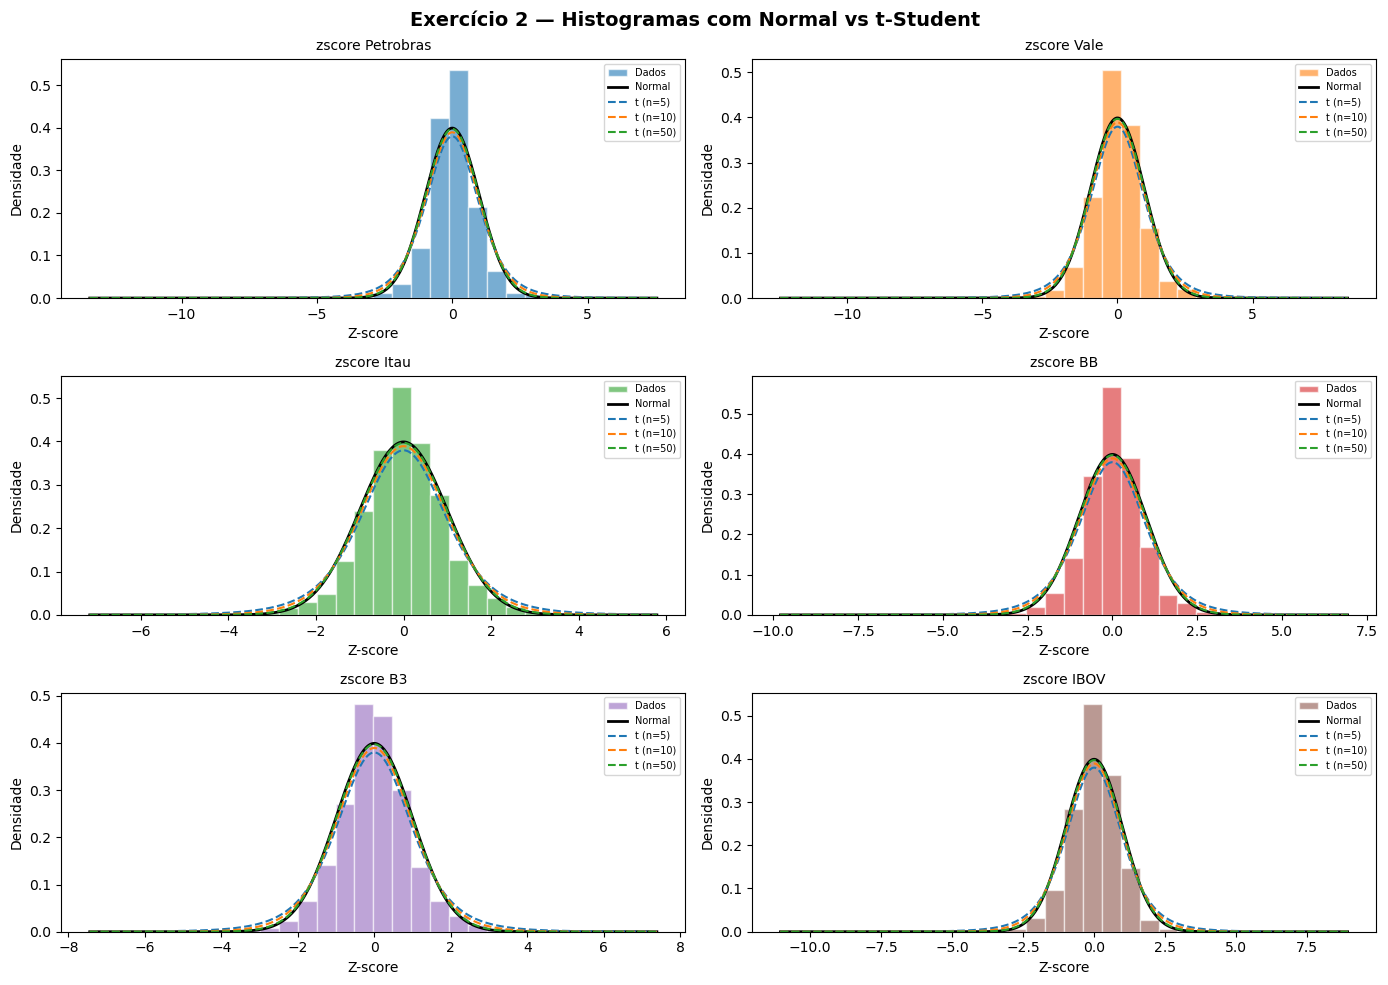

In [58]:
### Escreva aqui seu código para responder a questão 2.

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

ZCORES = [
    'zscore Petrobras',
    'zscore Vale',
    'zscore Itau',
    'zscore BB',
    'zscore B3',
    'zscore IBOV'
]

CORES = {
    'zscore Petrobras': '#1f77b4',
    'zscore Vale': '#ff7f0e',
    'zscore Itau': '#2ca02c',
    'zscore BB': '#d62728',
    'zscore B3': '#9467bd',
    'zscore IBOV': '#8c564b'
}


def plot_hist_com_curvas(ax, dados, titulo, cor):
    dados = dados.dropna()
    
    mu = dados.mean()
    sigma = dados.std()
    
    x = np.linspace(dados.min(), dados.max(), 500)
    
    ax.hist(dados, bins=30, density=True, alpha=0.6, color=cor, edgecolor='white', label='Dados')
    
    ax.plot(x, norm.pdf(x, mu, sigma), color='black', lw=2, label='Normal')
    
    
    for n in [5, 10, 50]:
        ax.plot(x, t.pdf(x, df=n, loc=mu, scale=sigma),
                linestyle='--', lw=1.5, label=f't (n={n})')
    
    
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('Z-score')
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=7)


fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Exercício 2 — Histogramas com Normal vs t-Student', fontsize=14, fontweight='bold')

for i, col in enumerate(ZCORES):
    ax = axes[i // 2, i % 2]
    plot_hist_com_curvas(ax, df[col], col, CORES[col])

plt.tight_layout()
plt.savefig("questao2_histogramas.png", dpi=120, bbox_inches='tight')
plt.show()

# Para responder a parte interpretativa, crie uma nova célula de texto!
# O que difere a curva T-Student e a curva gaussiana é que a T-Student tem caudas mais pesadas que a normal, ou seja, considera mais provável ocorrerem valores extremos.
# Conforme aumentam os graus de liberdade, ela fica cada vez mais parecida com a curva normal ou a gaussiana

**Questão 03 - Considerando que os log retornos são normais, calcule a probabilidade de termos um retorno acima de 3%**

In [59]:
### Escreva aqui seu código para responder a questão 3.

from scipy.stats import norm

COLUNAS = [
    'retorno_log1',
    'retorno_log2',
    'retorno_log3',
    'retorno_log4',
    'retorno_log5',
    'retorno_log6'
]

NOMES = ['Petrobras', 'Vale', 'Itau', 'BB', 'B3', 'IBOV']

print(f"\n{'Ação':<16} {'P(retorno > 3%)':>10}")
print("-" * 30)

for col, nome in zip(COLUNAS, NOMES):
    retorno = df[col]

    media = retorno.mean()
    std = retorno.std()

    prob_pos3 = 1 - norm.cdf(0.03, media, std)

    print(f"{nome:<16} {prob_pos3*100:>9.2f}%")


Ação             P(retorno > 3%)
------------------------------
Petrobras            13.70%
Vale                  9.90%
Itau                  5.19%
BB                    9.75%
B3                   10.84%
IBOV                  2.13%


**Questão 04 - Plote a PDF e a CDF dos log-retornos do seu portfólio.**

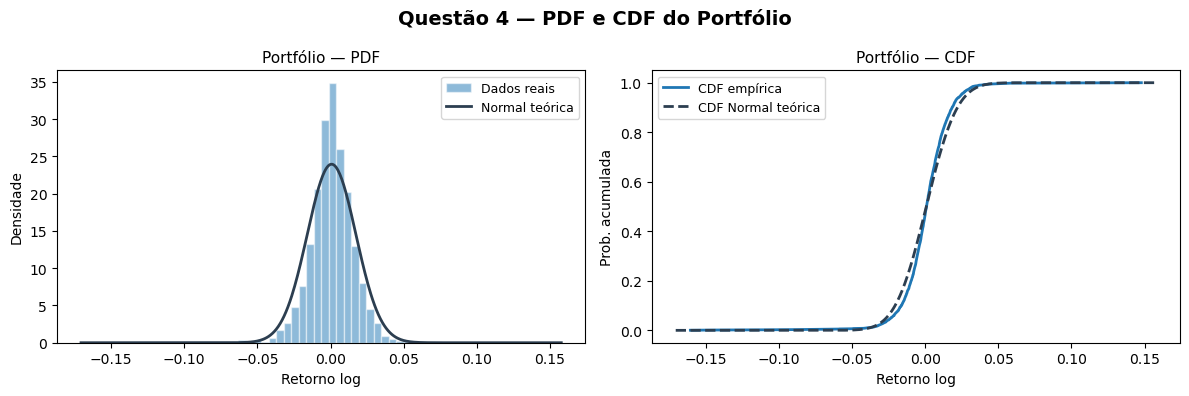

In [60]:
### Escreva aqui seu código para responder a questão 4.

df['retorno_portfolio'] = df[COLUNAS].mean(axis=1)
r = df['retorno_portfolio'].dropna()
med = r.mean()
std = r.std()
x = np.linspace(r.min() - 0.01, r.max() + 0.01, 500)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Questão 4 — PDF e CDF do Portfólio", fontsize=14, fontweight="bold")

ax_pdf = axes[0]
ax_pdf.hist(r, bins=60, density=True, alpha=0.5, edgecolor="white", label="Dados reais")
ax_pdf.plot(x, norm.pdf(x, med, std), color="#2c3e50", lw=2, label="Normal teórica")

ax_pdf.set_title("Portfólio — PDF", fontsize=11)
ax_pdf.set_xlabel("Retorno log")
ax_pdf.set_ylabel("Densidade")
ax_pdf.legend(fontsize=9)


ax_cdf = axes[1]
r_sorted = np.sort(r)
cdf_emp = np.arange(1, len(r_sorted)+1) / len(r_sorted)

ax_cdf.plot(r_sorted, cdf_emp, lw=2, label="CDF empírica")
ax_cdf.plot(x, norm.cdf(x, med, std), color="#2c3e50", lw=2,
            linestyle="--", label="CDF Normal teórica")

ax_cdf.set_title("Portfólio — CDF", fontsize=11)
ax_cdf.set_xlabel("Retorno log")
ax_cdf.set_ylabel("Prob. acumulada")
ax_cdf.legend(fontsize=9)


plt.tight_layout()
plt.savefig("questao4_portfolio_pdf_cdf.png", dpi=130, bbox_inches="tight")
plt.show()

**Questão 05 - Encontre kurtosis e skewness do retornos logarítmicos do seu portfólio. Qual o significado dessas medidas? Quais são os valores para uma normal padrão e qual o significado da diferença desses valores para o seu portfólio e para uma normal padrão?**


In [61]:
### Escreva aqui seu código para responder a questão 5.

from scipy.stats import skew, kurtosis

df['retorno_portfolio'] = df[COLUNAS].mean(axis=1)
r = df['retorno_portfolio'].dropna()

NOMES = ['Petrobras', 'Vale', 'Itau', 'BB', 'B3', 'IBOV']
print(f"\n{'Ação':<12} {'Média':>10} {'Variância':>12} {'Desv.Pad':>10} {'Skewness':>10} {'Kurtosis':>10}")
print("-" * 70)


for col, nome in zip(COLUNAS, NOMES):
    r = df[col].dropna()
    
    media = r.mean()
    variancia = r.var()
    std = r.std()
    skw = skew(r)
    kurt = kurtosis(r)  # excesso (normal = 0)
    
    print(f"{nome:<12} {media:>10.6f} {variancia:>12.8f} {std:>10.6f} {skw:>10.4f} {kurt:>10.4f}")





Ação              Média    Variância   Desv.Pad   Skewness   Kurtosis
----------------------------------------------------------------------
Petrobras      0.001131   0.00069625   0.026387    -1.9440    24.9765
Vale           0.000846   0.00051280   0.022645    -0.5776    16.5862
Itau           0.000689   0.00032461   0.018017    -0.1485     3.9581
BB             0.000518   0.00051748   0.022748    -0.8136    13.0981
B3             0.000697   0.00056288   0.023725    -0.1113     4.9651
IBOV           0.000522   0.00021143   0.014541    -1.3690    20.3674


# Para responder a parte interpretativa, crie uma nova célula de texto!
# O significado dessas medidas é que a Skewness mede o quanto é inclinada para a direita ou esquerda, diferente da Kurtosis que mede o peso
# das caudas de distribuicao, logo a frequencia dos eventos.
# Aplicando nos resultados, eles mostram que a skewness negativa e kurtosis elevada para a maioria dos ativos, isso acaba indicando assimetria à esquerda e caudas pesadas. 
# Logo, significa que os retornos não seguem uma distribuição normal e apresentam maior probabilidade de eventos com perdas, maiores riscos.

**Questão 06 - Considerando que os retornos são normais, calcule o percentil 25% dos retornos e a porcentagem dos dias que teremos retornos negativos**

In [62]:
### Escreva aqui seu código para responder a questão 6.


print(f"{'Ativo':<12} {'Média':>10} {'Desv.Pad':>10} {'P25%':>10} {'P(r<0)':>10}")
print("-" * 60)

df['retorno_portfolio'] = df[COLUNAS].mean(axis=1)

for col, nome in zip(COLUNAS, NOMES):
    r = df[col].dropna()
    
    media = r.mean()
    std = r.std()
    
    p25 = norm.ppf(0.25, media, std)
    prob_neg = norm.cdf(0, media, std)
    
    print(f"{nome:<12} {media:>10.6f} {std:>10.6f} {p25*100:>9.2f}% {prob_neg*100:>9.2f}%")



r = df['retorno_portfolio'].dropna()
media = r.mean()
std = r.std()
p25 = norm.ppf(0.25, media, std)
prob_neg = norm.cdf(0, media, std)
print("-" * 60)
print(f"{'Portfolio':<12} {media:>10.6f} {std:>10.6f} {p25*100:>9.2f}% {prob_neg*100:>9.2f}%")




Ativo             Média   Desv.Pad       P25%     P(r<0)
------------------------------------------------------------
Petrobras      0.001131   0.026387     -1.67%     48.29%
Vale           0.000846   0.022645     -1.44%     48.51%
Itau           0.000689   0.018017     -1.15%     48.48%
BB             0.000518   0.022748     -1.48%     49.09%
B3             0.000697   0.023725     -1.53%     48.83%
IBOV           0.000522   0.014541     -0.93%     48.57%
------------------------------------------------------------
Portfolio      0.000734   0.016653     -1.05%     48.24%


**Questão 07 - O que é o máximo drawdown? Calcule o máximo drawdown do seu portfólio. Interprete o resultado.**


In [63]:
### Escreva aqui seu código para responder a questão 7.

df['retorno_portfolio'] = df[COLUNAS].mean(axis=1)
r = df['retorno_portfolio'].dropna()

acum = np.exp(r.cumsum())
pico = np.maximum.accumulate(acum)
drawdown = (acum - pico) / pico
maxdrawdown = drawdown.min()

print("\nCálculo de Máximo Drawdown do Portfólio")
print("-" * 50)
print(f"{'Maximo_drawdown':<20}: {maxdrawdown*100:.2f}%")


r = df['retorno_portfolio'].dropna()
vol_diaria = r.std()
print(f"Volatilidade diária: {vol_diaria:.4%}")




Cálculo de Máximo Drawdown do Portfólio
--------------------------------------------------
Maximo_drawdown     : -48.01%
Volatilidade diária: 1.6653%


# Para responder a parte interpretativa, crie uma nova célula de texto!
# O resultado que seria possivel de interpretar é que o maximo drawdown condiz com a maior perda acumulada, representando o maior pico de queda,
# e dessa forma pode se dizer que o portfolio chegou a perder quase metade do seu valor em relacao ao pico anterior, assim é possivel afirmar
# que o investidor pode ter um alto risco com esse portfolio, alta volatilidade diaria e uma alta possibilidade de perdas 

**Questão 08 - Teste se os retornos do portfólio são estatisticamente diferentes de zero e do retorno do índice BOVESPA. Qual alpha você utilizaria?**

In [64]:
### Escreva aqui seu código para responder a questão 8.


df['retorno_portfolio'] = df[COLUNAS].mean(axis=1)
alpha = 0.05
z_critico = norm.ppf(1 - alpha / 2)

print("\nTeste para todas as ações e do portfólio:")
print(f"\n{'Ativo':<16} {'Média':>10} {'Erro Pad.':>12} {'Z':>8} {'p-valor':>10} {'Decisão':>15}")
print("-" * 80)


for col, nome in zip(COLUNAS, NOMES):
    r = df[col].dropna()
    
    n = len(r)
    med = r.mean()
    std = r.std()
    
    ep = std / np.sqrt(n)
    z = med / ep
    pval = 2 * (1 - norm.cdf(abs(z)))
    
    dec = "REJEITA H0" if pval <= alpha else "Não rejeita H0"
    
    print(f"{nome:<16} {med:>10.6f} {ep:>12.6f} {z:>8.3f} {pval:>10.4f} {dec:>15}")


r = df['retorno_portfolio'].dropna()
n = len(r)
med = r.mean()
std = r.std()
ep = std / np.sqrt(n)
z = med / ep
pval = 2 * (1 - norm.cdf(abs(z)))
dec = "REJEITA H0" if pval <= alpha else "Não rejeita H0"
print(f"{'Portfolio':<16} {med:>10.6f} {ep:>12.6f} {z:>8.3f} {pval:>10.4f} {dec:>15}")


print("\nComparação com IBOV")
print(f"\n{'Comparação':<16} {'Dif.Média':>10} {'Erro Pad.':>12} {'Z':>8} {'p-valor':>10} {'Decisão':>15}")
print("-" * 80)

r_p = df['retorno_portfolio'].dropna()
r_ibov = df['retorno_log6'].dropna()
n_p = len(r_p)
n_i = len(r_ibov)
med_p = r_p.mean()
med_i = r_ibov.mean()
var_p = r_p.var()
var_i = r_ibov.var()
ep_diff = np.sqrt(var_p/n_p + var_i/n_i)
z2 = (med_p - med_i) / ep_diff
pval2 = 2 * (1 - norm.cdf(abs(z2)))
dec2 = "REJEITA H0" if pval2 <= alpha else "Não rejeita H0"

print(f"{'Port vs IBOV':<16} {(med_p-med_i):>10.6f} {ep_diff:>12.6f} {z2:>8.3f} {pval2:>10.4f} {dec2:>15}")
print(f"\nValor crítico: ±{z_critico:.4f}")


Teste para todas as ações e do portfólio:

Ativo                 Média    Erro Pad.        Z    p-valor         Decisão
--------------------------------------------------------------------------------
Petrobras          0.001131     0.000550    2.057     0.0397      REJEITA H0
Vale               0.000846     0.000472    1.792     0.0731  Não rejeita H0
Itau               0.000689     0.000376    1.834     0.0667  Não rejeita H0
BB                 0.000518     0.000474    1.092     0.2750  Não rejeita H0
B3                 0.000697     0.000494    1.409     0.1587  Não rejeita H0
IBOV               0.000522     0.000303    1.721     0.0852  Não rejeita H0
Portfolio          0.000734     0.000347    2.114     0.0346      REJEITA H0

Comparação com IBOV

Comparação        Dif.Média    Erro Pad.        Z    p-valor         Decisão
--------------------------------------------------------------------------------
Port vs IBOV       0.000212     0.000461    0.460     0.6455  Não rejeita H0

V

# Para responder a parte interpretativa, crie uma nova célula de texto!
# Eu utilizaria o alpha a 5% para o nivel de significancia, porque permite identificar alguns ativos no portfolio como diferentes de zero, de forma 
# que eu nao correria muito risco por falsos positivos e tambem por ser um dos mais utilizados em pesquisas.
